# Operator Validation and Comparison

In [1]:
import torch
import numpy as np
from pathlib import Path
from __init__ import *
from src.mesh_types import OpenFoam_Mesh
from src.operators import Gradient_Operator, Divergence_Operator, Laplacian_Operator
from src.mesh_utils.file_parsers import parse_openfoam_file
from pathlib import Path

## Cylinder Case

In [2]:
from utils.vtk_visual import CylinderCase_plotter
case_dir = Path('./cylinder/case.foam')
Mesh = OpenFoam_Mesh(openfoam_case_dir=case_dir, dtype=torch.float32, corrected=True)


Constructing Mesh...
   Problem is detected to be 2D, AD-FVM is set for 2D
   Loading Cell Centres from /constant/polyMesh/Cc
   Loading Cell Volumes from /0/Vc
   Loading Interpolation Weights from /constant/weights
   Loading Face Owners from /constant/polyMesh/owner
   Loading Face Neighbours from /constant/polyMesh/neighbour
   3 Boundary Conditions found in /constant/polyMesh/boundary
Total Mesh Initialization Time: 1.97sec

Setting Mesh non-orthogonal correction method: Over-Relaxed


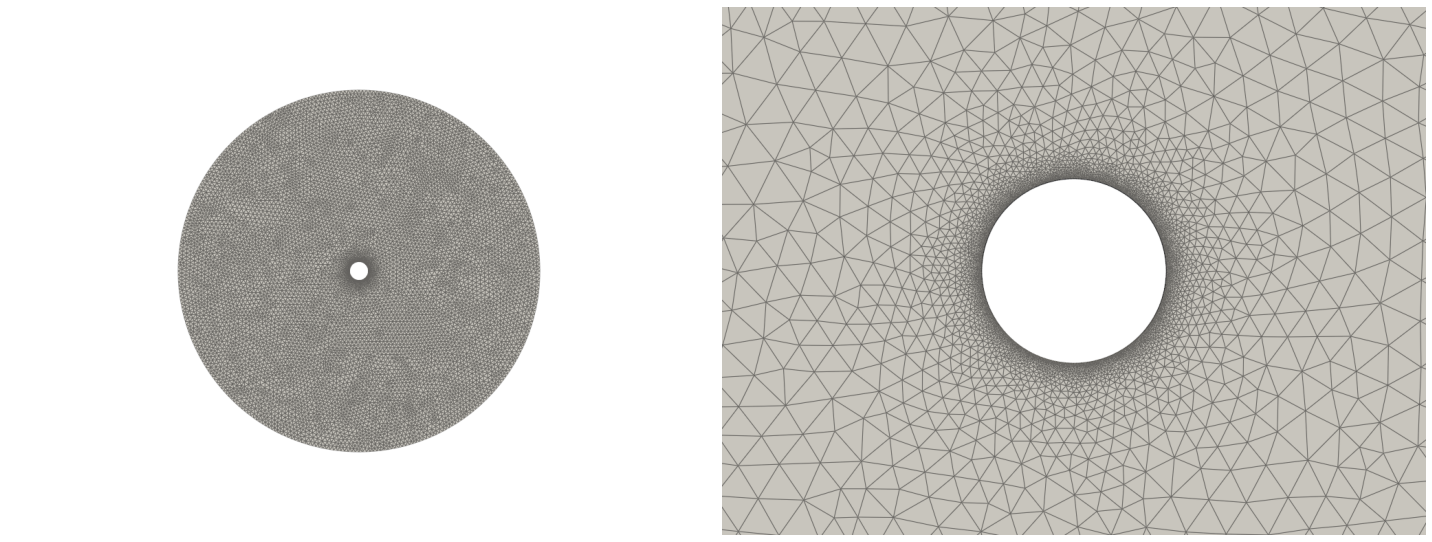

In [3]:
plotter = CylinderCase_plotter(case_dir)
plotter._add_scalar()
plotter._add_scalar(zoom_level=10)
plotter._collect_and_plot()

In [4]:
# collect into dataset
path = r'C:\Users\Noahc\Documents\USYD\tutorial\for_repo\cylinder'
solution_folder = '362'
assert (Path(path) / solution_folder).exists()

To generate these files to compare against, in OpenFOAM v12 use the following:
```[bash]
cd cylinder
postProcess -func "grad(U)" -time -latestTime
postProcess -func "grad(p)" -time -latestTime
postProcess -dict "system/eqn_functions" -latestTime
```
`div(U)` does not give the advected divergence, while our `Divergence_Operator` already advects with the field velocity. Hence we compare this to `divU_phi_all` which is generated using our custom `eqn_function` post-processing script. Additionally `divU_phi_all` differs from `div_U` in that it uses the uncorrected solution flux `phi`.

In [5]:
u_file,__ = parse_openfoam_file(Path(path) / solution_folder / 'U')
u_grad_file,__ = parse_openfoam_file(Path(path) / solution_folder / 'grad(U)')
u_div_file,__ = parse_openfoam_file(Path(path) / solution_folder / 'divU_phiAll')
u_lap_file,__ = parse_openfoam_file(Path(path) / solution_folder / 'lapU')
if Mesh.dim == 2:
    grad_labels = ['𝜕xU', '𝜕yU', '𝜕xV', '𝜕yV']
    div_labels = ['U𝜕xU + V𝜕yU', 'U𝜕xV + V𝜕yV', 'U𝜕xW + V𝜕yW']
    u_file = u_file[...,:2]
    u_grad_file = u_grad_file[...,[0,1,3,4]]
    u_div_file = u_div_file[...,:2]
    u_lap_file = u_lap_file[...,:2]
else:
    grad_labels = ['𝜕xU', '𝜕yU', '𝜕zU', '𝜕xV', '𝜕yV', '𝜕zV', '𝜕xW', '𝜕yW', '𝜕zW']
    div_labels = ['U𝜕xU + V𝜕yU + W𝜕zU', 'U𝜕xV + V𝜕yV + W𝜕zV', 'U𝜕xW + V𝜕yW + W𝜕zW']

### Gradient Field

In [6]:
gradient = Gradient_Operator.calculate(mesh=Mesh, input_field=torch.tensor(u_file,dtype=torch.float32), field_type='U')[0,0,...]

𝜕xV


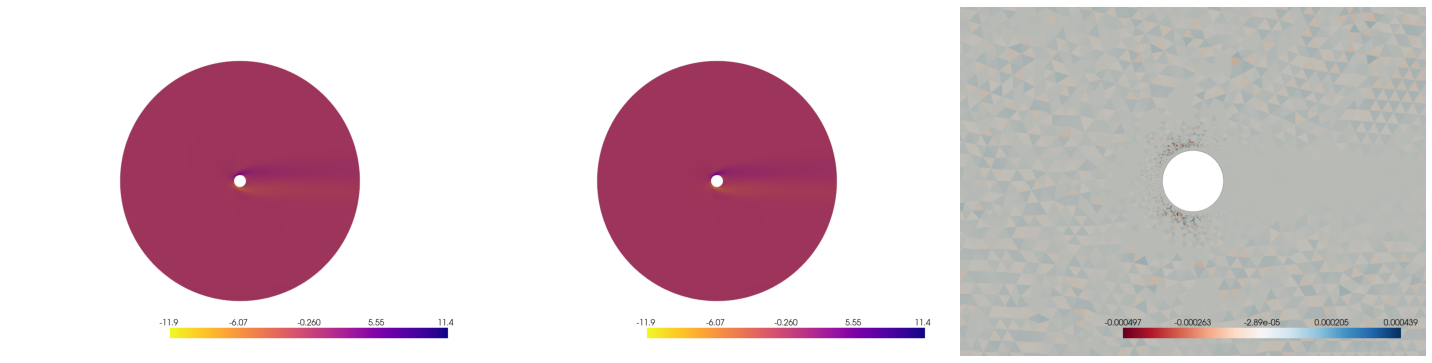

In [7]:
idx= 2
print(grad_labels[idx])
plotter = CylinderCase_plotter(case_dir)
plotter._add_scalar(gradient[...,idx], cmap='plasma_r')
plotter._add_scalar(u_grad_file[...,idx], cmap='plasma_r')
plotter._add_scalar(gradient[...,idx]-u_grad_file[...,idx], zoom_level=5, cmap='RdBu') #0,1,3,4
plotter._collect_and_plot()

### Divergence Field

In [8]:
divergence = Divergence_Operator.calculate(mesh=Mesh, input_field=torch.tensor(u_file,dtype=torch.float32), field_type='U')[0,0,...]

U𝜕xU + V𝜕yU


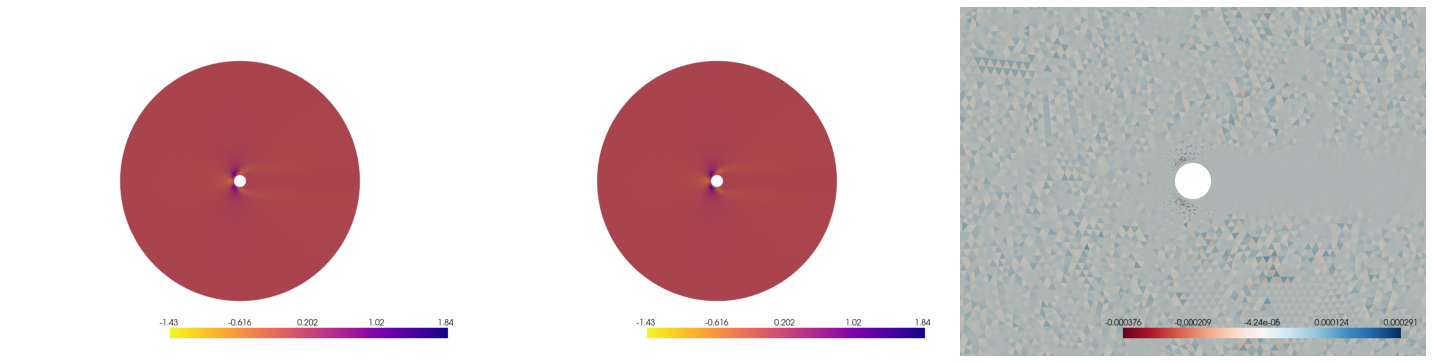

In [9]:
idx = 0
print(div_labels[idx])
plotter = CylinderCase_plotter(case_dir)
plotter._add_scalar(divergence[...,idx], cmap='plasma_r')
plotter._add_scalar(u_div_file[...,idx], cmap='plasma_r')
plotter._add_scalar(divergence[...,idx]-u_div_file[...,idx], zoom_level=3, cmap='RdBu') #0,1,3,4
plotter._collect_and_plot()

### Laplacian

In [7]:
Laplacian = Laplacian_Operator.calculate(mesh=Mesh, input_field=torch.tensor(u_file,dtype=torch.float32), field_type='U')[0,0,...]

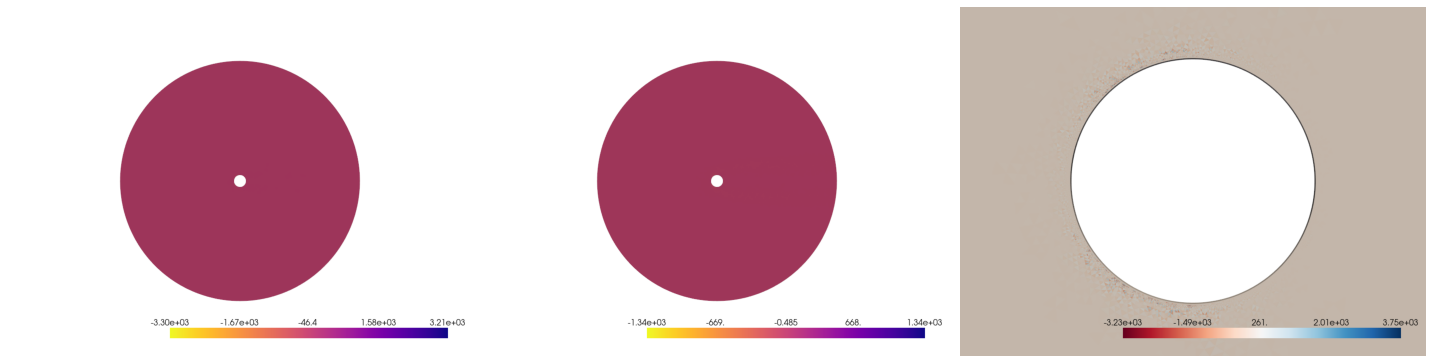

In [8]:
idx = 0
plotter = CylinderCase_plotter(case_dir)
plotter._add_scalar(Laplacian[...,idx], cmap='plasma_r')
plotter._add_scalar(u_lap_file[...,idx], cmap='plasma_r')
plotter._add_scalar(Laplacian[...,idx]-u_lap_file[...,idx], zoom_level=20, cmap='RdBu') #0,1,3,4
plotter._collect_and_plot()

The underlying Solver has a non-orthogonal correction. We apply the same correction here. By default our Mesh object assumes `method='Over-Relaxed'` calculation even for the *Implicit* Laplacian. To set a fully native `Orthogonal` calculation, call the following prior to any operators:
```[python]
Mesh._set_orthogonal_method(None)
```
Other techniques such as the *Minimum Correction* and *Orthogonal Correction* are also included but not verified.

Below demonstrates how added the expected **Non-Orthogonal Correction** significantly reduces the Laplacian calculation error between OpenFOAM and our AD-FVM Framework.

In [10]:
Laplacian += Laplacian_Operator.correction(mesh=Mesh, input_field=torch.tensor(u_file,dtype=torch.float32), 
                                           field_type='U',grad_field=gradient.unsqueeze(0).unsqueeze(0))[0,0,...]

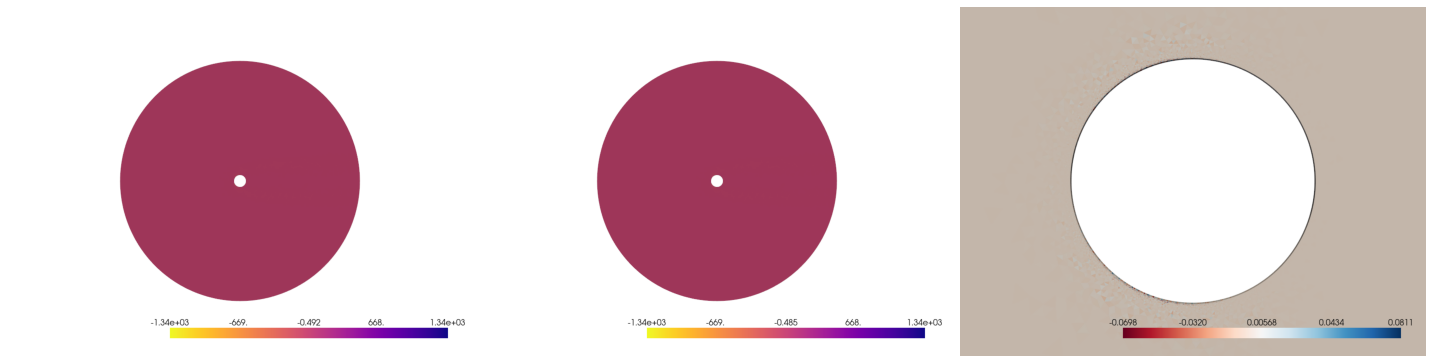

In [11]:
idx = 0
plotter = CylinderCase_plotter(case_dir)
plotter._add_scalar(Laplacian[...,idx], cmap='plasma_r')
plotter._add_scalar(u_lap_file[...,idx], cmap='plasma_r')
plotter._add_scalar(Laplacian[...,idx]-u_lap_file[...,idx], zoom_level=20, cmap='RdBu') #0,1,3,4
plotter._collect_and_plot()